In [1]:
import h5py
import glob
import numpy as np
import matplotlib.pyplot as plt
from pycbc import conversions

/work/yifanwang/o4a_ecc/env/lib/python3.11/site-packages/pycbc/types/array.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal as _lal


In [2]:
file_list = glob.glob('o4a-eccbank-*.hdf') + glob.glob('./odd_num/o4a-eccbank-*.hdf')

In [4]:
len(file_list)

87

In [5]:
data = {}

for fname in file_list:
    print(fname)
    f = h5py.File(fname, 'r')
    for k in f:
        if k not in data:
            data[k] = []
        data[k].append(f[k][()])

for k in data:
    data[k] = np.concatenate(data[k])


o = h5py.File('combine-o4a-ecc.hdf', 'w')
for k in data:
    if k == 'template_s':
        continue
    o[k] = data[k]
o.close()

o4a-eccbank-40.hdf
o4a-eccbank-10.hdf
o4a-eccbank-0.hdf
o4a-eccbank-82.hdf
o4a-eccbank-44.hdf
o4a-eccbank-16.hdf
o4a-eccbank-38.hdf
o4a-eccbank-46.hdf
o4a-eccbank-54.hdf
o4a-eccbank-74.hdf
o4a-eccbank-24.hdf
o4a-eccbank-18.hdf
o4a-eccbank-22.hdf
o4a-eccbank-48.hdf
o4a-eccbank-58.hdf
o4a-eccbank-42.hdf
o4a-eccbank-36.hdf
o4a-eccbank-14.hdf
o4a-eccbank-34.hdf
o4a-eccbank-86.hdf
o4a-eccbank-56.hdf
o4a-eccbank-70.hdf
o4a-eccbank-62.hdf
o4a-eccbank-20.hdf
o4a-eccbank-26.hdf
o4a-eccbank-64.hdf
o4a-eccbank-32.hdf
o4a-eccbank-60.hdf
o4a-eccbank-76.hdf
o4a-eccbank-12.hdf
o4a-eccbank-80.hdf
o4a-eccbank-8.hdf
o4a-eccbank-52.hdf
o4a-eccbank-84.hdf
o4a-eccbank-50.hdf
o4a-eccbank-78.hdf
o4a-eccbank-6.hdf
o4a-eccbank-72.hdf
o4a-eccbank-4.hdf
o4a-eccbank-66.hdf
o4a-eccbank-68.hdf
o4a-eccbank-30.hdf
o4a-eccbank-2.hdf
o4a-eccbank-28.hdf
./odd_num/o4a-eccbank-23.hdf
./odd_num/o4a-eccbank-53.hdf
./odd_num/o4a-eccbank-49.hdf
./odd_num/o4a-eccbank-7.hdf
./odd_num/o4a-eccbank-45.hdf
./odd_num/o4a-eccbank-41.

In [7]:
data

{'approximant': array([b'SEOBNRv5E', b'SEOBNRv5E', b'SEOBNRv5E', ..., b'SEOBNRv5E',
        b'SEOBNRv5E', b'SEOBNRv5E'], shape=(2877175,), dtype='|S9'),
 'eccentricity': array([0.04334611, 0.0373502 , 0.23112125, ..., 0.33263122, 0.3314195 ,
        0.32947267], shape=(2877175,)),
 'f_lower': array([20., 20., 20., ..., 20., 20., 20.], shape=(2877175,)),
 'mass1': array([ 7.89991185,  8.42863021,  8.44394713, ..., 16.95943363,
        16.4959106 , 16.57144892], shape=(2877175,)),
 'mass2': array([7.39605434, 6.8160785 , 6.80132412, ..., 5.01059311, 5.02167533,
        5.0199462 ], shape=(2877175,)),
 'rel_anomaly': array([2.34784176, 1.2506846 , 5.21606478, ..., 3.61314009, 5.81167259,
        2.21390414], shape=(2877175,)),
 'spin1z': array([ 0.11565659, -0.05637417,  0.47392473, ..., -0.06163882,
         0.44580876, -0.2683079 ], shape=(2877175,)),
 'spin2z': array([ 0.1908174 , -0.26715009, -0.6729784 , ..., -0.50334173,
         0.27653595, -0.66376373], shape=(2877175,)),
 'templa

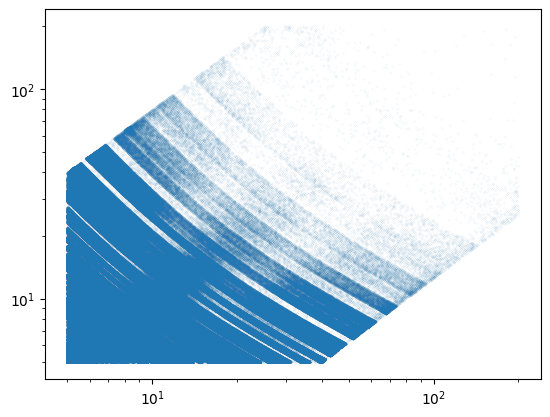

In [8]:
plt.scatter(data['mass1'], data['mass2'], s=0.001)
plt.xscale('log')
plt.yscale('log')

In [10]:
mc = conversions.mchirp_from_mass1_mass2(data['mass1'], data['mass2'])

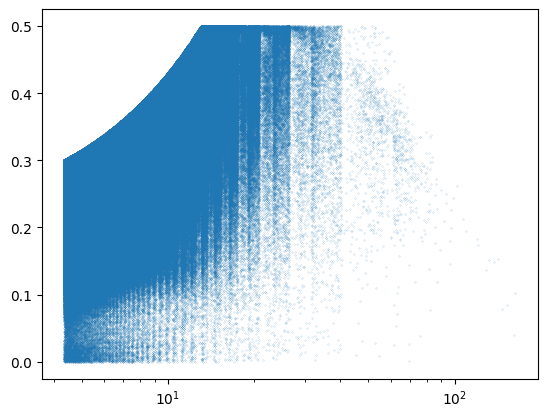

In [11]:
plt.scatter(mc, data['eccentricity'], s=0.01)
plt.xscale('log')

In [12]:
chieff = conversions.chi_eff(data['mass1'],data['mass2'],data['spin1z'],data['spin2z'])

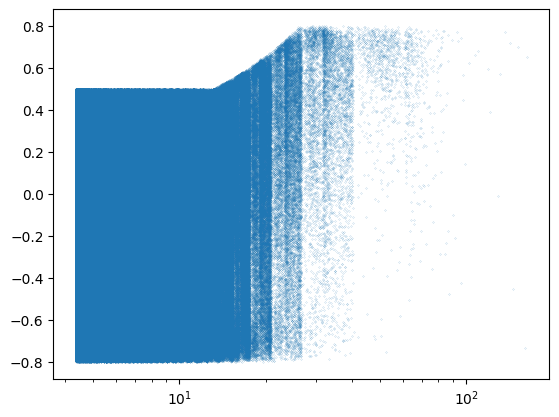

In [13]:
plt.scatter(mc, chieff, s=0.01)
plt.xscale('log')